# Section A: Portfolio Fundamentals & Risk Metrics (40 marks)

## Problem 1: Portfolio Construction & Daily Returns

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = {
    'RELIANCE': [2800, 2850, 2830, 2900, 2880, 2950],
    'INFY': [1450, 1470, 1460, 1490, 1510, 1500],
    'HDFCBANK': [1600, 1580, 1610, 1625, 1615, 1640],
    'TATAMOTORS': [520, 535, 528, 540, 555, 548]
}
days = ['Day 1', 'Day 2', 'Day 3', 'Day 4', 'Day 5', 'Day 6']
prices_df = pd.DataFrame(data, index=days)

# Compute daily percentage returns
returns_df = prices_df.pct_change().dropna()

print("--- Prices DataFrame ---")
print(prices_df)
print("\n--- Daily Percentage Returns Matrix ---")
print(returns_df)

--- Prices DataFrame ---
       RELIANCE  INFY  HDFCBANK  TATAMOTORS
Day 1      2800  1450      1600         520
Day 2      2850  1470      1580         535
Day 3      2830  1460      1610         528
Day 4      2900  1490      1625         540
Day 5      2880  1510      1615         555
Day 6      2950  1500      1640         548

--- Daily Percentage Returns Matrix ---
       RELIANCE      INFY  HDFCBANK  TATAMOTORS
Day 2  0.017857  0.013793 -0.012500    0.028846
Day 3 -0.007018 -0.006803  0.018987   -0.013084
Day 4  0.024735  0.020548  0.009317    0.022727
Day 5 -0.006897  0.013423 -0.006154    0.027778
Day 6  0.024306 -0.006623  0.015480   -0.012613


--- Units Purchased on Day 1 ---
RELIANCE: 89.2857 units
INFY: 172.4138 units
HDFCBANK: 156.2500 units
TATAMOTORS: 480.7692 units

--- Daily Portfolio Value ---
Day 1    1.000000e+06
Day 2    1.011999e+06
Day 3    1.009811e+06
Day 4    1.029347e+06
Day 5    1.036658e+06
Day 6    1.041725e+06
dtype: float64


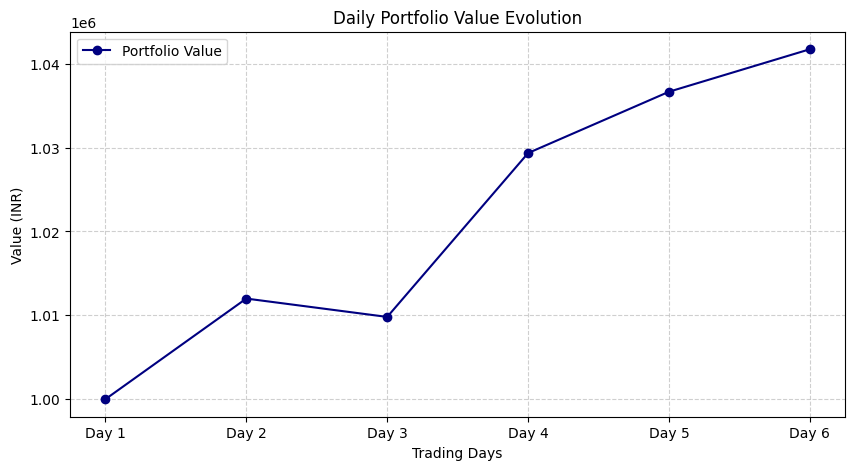

In [26]:
# b) Portfolio calculation using vectorized approach
initial_capital = 1000000
weights = np.array([0.25, 0.25, 0.25, 0.25])

# Calculate allocation per asset on Day 1
allocation = initial_capital * weights
day1_prices = prices_df.iloc[0].values
units = allocation / day1_prices

# Compute daily portfolio values using matrix dot product
portfolio_values = prices_df.dot(units)

print("--- Units Purchased on Day 1 ---")
for asset, unit in zip(prices_df.columns, units):
    print(f"{asset}: {unit:.4f} units")

print("\n--- Daily Portfolio Value ---")
print(portfolio_values)

# Plotting the Portfolio Value over time
plt.figure(figsize=(10, 5))
plt.plot(portfolio_values.index, portfolio_values.values, marker='o', color='navy', label='Portfolio Value')
plt.title('Daily Portfolio Value Evolution')
plt.xlabel('Trading Days')
plt.ylabel('Value (INR)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [27]:
# c) Compute annualised volatility
daily_returns = portfolio_values.pct_change().dropna()
daily_volatility = daily_returns.std()
annualised_volatility = daily_volatility * np.sqrt(252)

print(f"Daily Portfolio Volatility: {daily_volatility:.6f}")
print(f"Annualised Portfolio Volatility: {annualised_volatility:.4%}")


Daily Portfolio Volatility: 0.008034
Annualised Portfolio Volatility: 12.7539%


## Problem 2: Risk Metrics VaR, CVaR, and Drawdowns

### Code Cell: Generating Synthetic Returns & Computing Metrics

In [28]:
np.random.seed(42)

sim_returns = np.random.normal(loc=0.001, scale=0.015, size=50)

# a) Compute Historical Value at Risk (VaR)
var_95 = -np.percentile(sim_returns, 5)
var_99 = -np.percentile(sim_returns, 1)

print(f"95% Historical VaR: {var_95:.4%}")
print(f"99% Historical VaR: {var_99:.4%}")


95% Historical VaR: 2.5188%
99% Historical VaR: 2.8054%



* **95% VaR:** There is a 5% chance that the portfolio will lose more than $VaR_{95}$ on any given trading day. Alternatively, we are 95% confident that our daily losses will not exceed this value.
* **99% VaR:** There is a 1% chance that the daily loss will exceed $VaR_{99}$. This represents a more extreme tail event than the 95% threshold.


In [29]:
# b) Compute Conditional VaR (CVaR)
cvar_95 = -sim_returns[sim_returns <= -var_95].mean()
cvar_99 = -sim_returns[sim_returns <= -var_99].mean()

print(f"95% Conditional VaR (CVaR): {cvar_95:.4%}")
print(f"99% Conditional VaR (CVaR): {cvar_99:.4%}")

95% Conditional VaR (CVaR): 2.7180%
99% Conditional VaR (CVaR): 2.8395%


> **Why CVaR is more informative:** VaR only tells us a threshold value below which a certain percentage of returns fall, completely ignoring the magnitude of the losses beyond that point. CVaR quantifies the *expected value* of the loss given that the threshold has been breached (the expected worst-case loss), providing a truer assessment of extreme tail risk.


Maximum Drawdown (MaxDD): 18.1649%


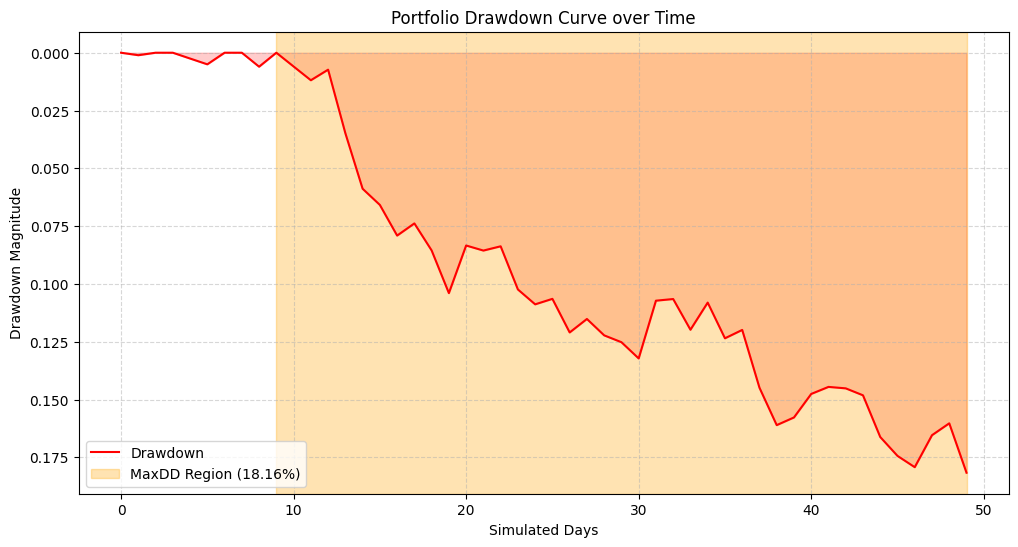

In [30]:
# c) Maximum Drawdown Calculation & Plotting
# Reconstruct cumulative portfolio wealth starting from 1,000,000
sim_portfolio_values = initial_capital * np.cumprod(1 + sim_returns)
sim_portfolio_series = pd.Series(sim_portfolio_values)

# Rolling peak value
rolling_peak = sim_portfolio_series.cummax()
drawdowns = (rolling_peak - sim_portfolio_series) / rolling_peak
max_dd = drawdowns.max()

# Identify locations of peak and trough for plotting
trough_idx = drawdowns.idxmax()
peak_idx = sim_portfolio_series.loc[:trough_idx].idxmax()

print(f"Maximum Drawdown (MaxDD): {max_dd:.4%}")

# Plot drawdown curve
plt.figure(figsize=(12, 6))
plt.plot(drawdowns.index, drawdowns.values, color='red', label='Drawdown')
plt.fill_between(drawdowns.index, drawdowns.values, color='red', alpha=0.2)
plt.axvspan(peak_idx, trough_idx, color='orange', alpha=0.3, label=f'MaxDD Region ({max_dd:.2%})')
plt.title('Portfolio Drawdown Curve over Time')
plt.xlabel('Simulated Days')
plt.ylabel('Drawdown Magnitude')
plt.gca().invert_yaxis()  # Standard way to plot drawdowns downwards
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()


## Problem 3: Risk-Adjusted Performance Metrics


In [31]:
np.random.seed(42)

p_returns = np.random.normal(loc=0.0012, scale=0.015, size=252)
rf_annual = 0.06
rf_daily = rf_annual / 252

# a) Sharpe Ratio
ann_return = np.mean(p_returns) * 252
ann_vol = np.std(p_returns) * np.sqrt(252)
sharpe_ratio = (ann_return - rf_annual) / ann_vol

# b) Sortino Ratio
negative_returns = p_returns[p_returns < 0]
downside_deviation_daily = np.sqrt(np.mean(negative_returns ** 2))
downside_deviation_ann = downside_deviation_daily * np.sqrt(252)
sortino_ratio = (ann_return - rf_annual) / downside_deviation_ann

# c) Comparison DataFrame
metrics_df = pd.DataFrame({
    'Metric': ['Annualised Return', 'Annualised Volatility', 'Downside Deviation', 'Sharpe Ratio', 'Sortino Ratio'],
    'Value': [f"{ann_return:.4%}", f"{ann_vol:.4%}", f"{downside_deviation_ann:.4%}", f"{sharpe_ratio:.4f}", f"{sortino_ratio:.4f}"]
})
print(metrics_df.to_string(index=False))


               Metric    Value
    Annualised Return 28.8169%
Annualised Volatility 22.9854%
   Downside Deviation 22.0030%
         Sharpe Ratio   0.9927
        Sortino Ratio   1.0370


> **Why Sortino penalises high upside volatility less:** The Sharpe ratio utilizes the standard deviation of *all* returns in its denominator, implicitly penalizing large positive returns as "risk" even though they are highly desirable to investors. The Sortino ratio exclusively isolates negative returns to calculate downside risk. Therefore, if a portfolio exhibits a strong right-skewed profile (frequent large gains), its Sharpe ratio will artificially drop, while its Sortino ratio remains healthily high.
> **Strategy Appropriateness:** For an **asymmetrically returning strategy** (such as a trend-following or options-buying strategy), the **Sortino Ratio** is far more appropriate because it ignores the beneficial noise generated by outsized profit streaks.

## Problem 4: Backtesting a Simple Moving Average Strategy


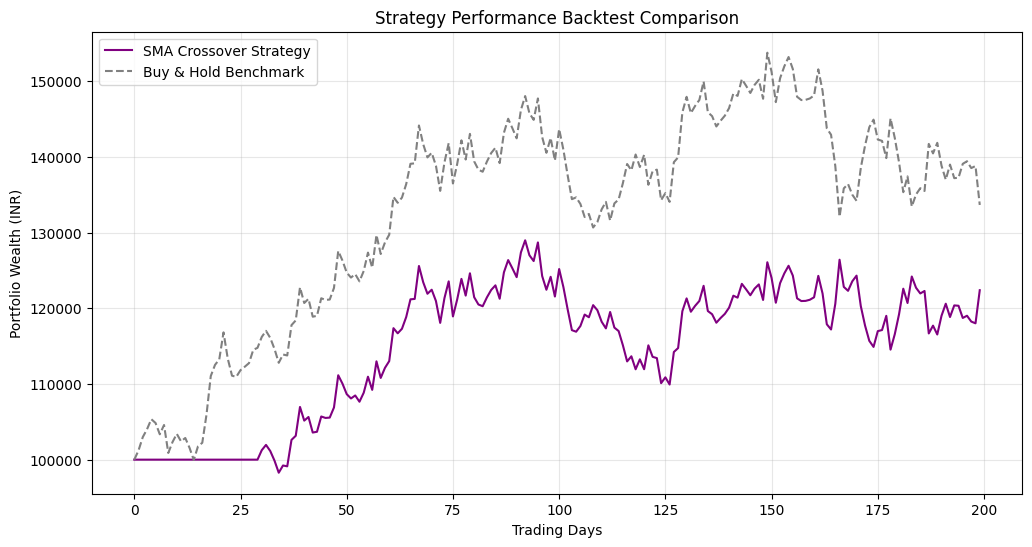

In [32]:
np.random.seed(101)
# Generate price series with a random walk
P_0 = 1000
days = 200
epsilon = np.random.normal(0.001, 0.018, days)

prices = [P_0]
for e in epsilon:
    prices.append(prices[-1] * (1 + e))
prices_series = pd.Series(prices[1:], name='Price')

# a) Implement SMA Crossover
sma_10 = prices_series.rolling(window=10).mean()
sma_30 = prices_series.rolling(window=30).mean()

# Generate Signals: +1 when SMA_10 > SMA_30, -1 otherwise (ignoring NaN warmup initially)
signal = np.where(sma_10 > sma_30, 1, -1)
signal[:29] = 0  # Warmup period context

strategy_df = pd.DataFrame({
    'Price': prices_series,
    'SMA_10': sma_10,
    'SMA_30': sma_30,
    'Signal': signal
})

# b) Backtest Simulation
initial_cap = 100000
strategy_df['Asset_Return'] = strategy_df['Price'].pct_change().fillna(0)
# Shift signals by 1 day to prevent look-ahead bias (execute trade based on previous day's closing cross)
strategy_df['Strat_Return'] = strategy_df['Signal'].shift(1).fillna(0) * strategy_df['Asset_Return']

strategy_df['Cum_BH'] = initial_cap * (1 + strategy_df['Asset_Return']).cumprod()
strategy_df['Cum_Strat'] = initial_cap * (1 + strategy_df['Strat_Return']).cumprod()

# Plot Cumulative Performance
plt.figure(figsize=(12, 6))
plt.plot(strategy_df['Cum_Strat'], label='SMA Crossover Strategy', color='purple')
plt.plot(strategy_df['Cum_BH'], label='Buy & Hold Benchmark', color='gray', linestyle='--')
plt.title('Strategy Performance Backtest Comparison')
plt.xlabel('Trading Days')
plt.ylabel('Portfolio Wealth (INR)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [33]:
# c) Trade performance evaluation
# Identify trade outcomes by tracking non-zero return returns
trade_returns = strategy_df['Strat_Return'][strategy_df['Signal'].shift(1) != 0]

winning_trades = np.sum(trade_returns > 0)
total_trades = np.sum(trade_returns != 0)
win_rate = winning_trades / total_trades if total_trades > 0 else 0

total_profit = np.sum(trade_returns[trade_returns > 0])
total_loss = np.abs(np.sum(trade_returns[trade_returns < 0]))
profit_factor = total_profit / total_loss if total_loss > 0 else np.nan

print(f"Total Active Trading Days: {total_trades}")
print(f"Win Rate: {win_rate:.2%}")
print(f"Profit Factor: {profit_factor:.4f}")


Total Active Trading Days: 170
Win Rate: 51.76%
Profit Factor: 1.1989


> **Does a Profit Factor > 1 guarantee a good strategy?** Not necessarily. While a profit factor greater than $1$ signals that the backtest generated more absolute profit than loss, it fails to account for execution realities. It does not control for high maximum drawdowns, long stagnation periods, transaction fees, market impact slippage, or data-snooping biases which can completely degrade live performance.


# Section B: Machine Learning Applications (45 marks)

## Problem 5: Feature Engineering for ML Models


Class Counts:
 Target
1    151
0    129
Name: count, dtype: int64


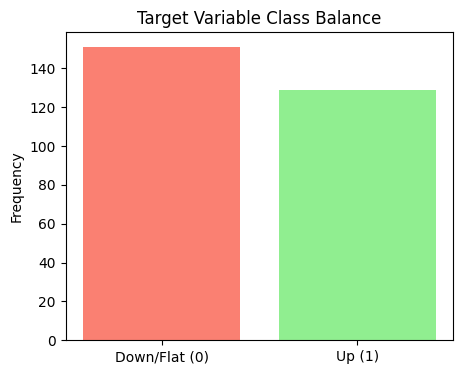

In [34]:
np.random.seed(42)
P_0 = 500
sim_days = 300
epsilons = np.random.normal(0.001, 0.018, sim_days)

p_list = [P_0]
for ep in epsilons:
    p_list.append(p_list[-1] * (1 + ep))
p_series = pd.Series(p_list[1:])

# a) Manual Feature Calculations
df_ml = pd.DataFrame({'Price': p_series})
df_ml['Return_1d'] = df_ml['Price'].pct_change()
df_ml['SMA_5'] = df_ml['Price'].rolling(5).mean()
df_ml['SMA_20'] = df_ml['Price'].rolling(20).mean()
df_ml['Volatility_10'] = df_ml['Return_1d'].rolling(10).std()
df_ml['Momentum_5'] = df_ml['Price'] - df_ml['Price'].shift(5)

# Drop rows containing NaNs and reset index
df_ml = df_ml.dropna().reset_index(drop=True)

# b) Binary Target Setup
# Target variable is 1 if tomorrow's return is positive, 0 otherwise
df_ml['Target'] = np.where(df_ml['Return_1d'].shift(-1) > 0, 1, 0)
df_ml = df_ml.iloc[:-1].copy()

# Visualise Class Balance
counts = df_ml['Target'].value_counts()
print("Class Counts:\n", counts)

plt.figure(figsize=(5, 4))
plt.bar(['Down/Flat (0)', 'Up (1)'], counts.values, color=['salmon', 'lightgreen'])
plt.title('Target Variable Class Balance')
plt.ylabel('Frequency')
plt.show()


In [35]:
# c) Manual Min-Max Normalisation Implementation
feature_cols = ['Return_1d', 'SMA_5', 'SMA_20', 'Volatility_10', 'Momentum_5']
X_raw = df_ml[feature_cols].values
y = df_ml['Target'].values

X_min = X_raw.min(axis=0)
X_max = X_raw.max(axis=0)
X_scaled = (X_raw - X_min) / (X_max - X_min)

print("First scaled feature row sample:\n", X_scaled[0])


First scaled feature row sample:
 [0.25781843 0.31632762 0.46152333 0.22679817 0.23348484]


> **Why feature scaling is critical for KNN:** KNN makes classification choices strictly by measuring the Euclidean distance between sample vectors. If features populate vastly different numeric spans (e.g., raw dollar Momentum spanning $\pm 50$ vs standard deviations sizing below $0.03$), the absolute magnitude variations of the larger feature will mathematically overwhelm the distance calculations, stripping the smaller feature of its predictive influence.

## Problem 6: K-Nearest Neighbours (KNN) From Scratch


Accuracy for k=3: 0.5893
Accuracy for k=5: 0.5179
Accuracy for k=7: 0.5536
Accuracy for k=11: 0.4464
Accuracy for k=15: 0.6071


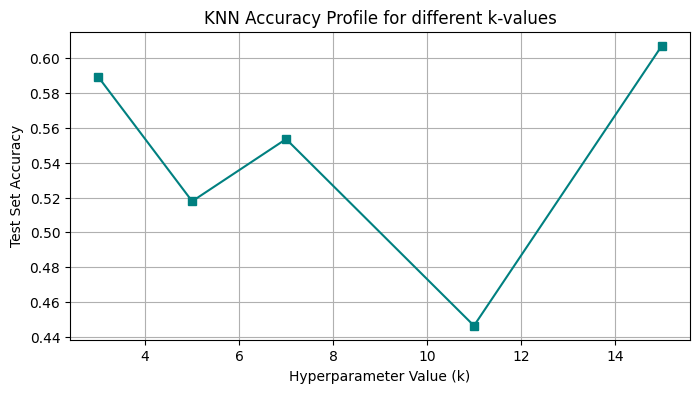

Optimal Hyperparameter is k = 15


In [36]:
# a) KNN From Scratch Code functions
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2, axis=1))

def knn_predict(X_train, y_train, X_test, k):
    predictions = []
    for test_point in X_test:
        # Distance calculation vectorized against all training vectors
        distances = euclidean_distance(X_train, test_point)
        # Sort indices to fetch nearest k points
        k_nearest_indices = np.argsort(distances)[:k]
        k_nearest_labels = y_train[k_nearest_indices]
        # Identify majority class
        counts = np.bincount(k_nearest_labels)
        predictions.append(np.argmax(counts))
    return np.array(predictions)

# b) Train-Test Partitioning (80/20 chronological split to protect sequence structure)
split_idx = int(0.8 * len(X_scaled))
X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

k_values = [3, 5, 7, 11, 15]
accuracies = []

for k in k_values:
    preds = knn_predict(X_train, y_train, X_test, k)
    acc = np.mean(preds == y_test)
    accuracies.append(acc)
    print(f"Accuracy for k={k}: {acc:.4f}")

# Plot Accuracy vs K Curve
plt.figure(figsize=(8, 4))
plt.plot(k_values, accuracies, marker='s', color='teal', linestyle='-')
plt.title('KNN Accuracy Profile for different k-values')
plt.xlabel('Hyperparameter Value (k)')
plt.ylabel('Test Set Accuracy')
plt.grid(True)
plt.show()

optimal_k = k_values[np.argmax(accuracies)]
print(f"Optimal Hyperparameter is k = {optimal_k}")


In [37]:
# c) Confusion Matrix Generation for Best k
best_preds = knn_predict(X_train, y_train, X_test, optimal_k)

TP = np.sum((best_preds == 1) & (y_test == 1))
FP = np.sum((best_preds == 1) & (y_test == 0))
TN = np.sum((best_preds == 0) & (y_test == 0))
FN = np.sum((best_preds == 0) & (y_test == 1))

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0

print(f"Confusion Matrix Metrics -> TP: {TP}, FP: {FP}, TN: {TN}, FN: {FN}")
print(f"Precision: {precision:.4f} | Recall: {recall:.4f}")


Confusion Matrix Metrics -> TP: 21, FP: 15, TN: 13, FN: 7
Precision: 0.5833 | Recall: 0.7500


> **Precision vs Recall Priority:** In automated execution where false positives are highly costly, **Precision** is significantly more important. A false positive means the model predicts the market will rise (triggering a buy long signal), but it actually falls, incurring direct financial losses and transaction costs. Maximizing Precision ensures that when the system decides to risk capital, it exhibits a high probability of being correct.


## Problem 7: Linear Regression Return Prediction from Scratch


In [38]:
# a) Normal Equation Framework
# Setup continuous next-day return target
y_cont = df_ml['Return_1d'].shift(-1).iloc[:-1].values
X_lr = X_scaled[:-1] # Sync observations lengths

# Intercept Prepending
X_bias = np.hstack([np.ones((X_lr.shape[0], 1)), X_lr])

# Train-Test Split (80/20)
lr_split = int(0.8 * len(X_bias))
X_train_lr, X_test_lr = X_bias[:lr_split], X_bias[lr_split:]
y_train_lr, y_test_lr = y_cont[:lr_split], y_cont[lr_split:]

# Calculate weights via Closed Form Normal Equation: beta = (X^T * X)^(-1) * X^T * y
beta = np.linalg.inv(X_train_lr.T @ X_train_lr) @ X_train_lr.T @ y_train_lr

print("Learned Analytical Coefficients:")
feature_names = ['Bias/Intercept'] + feature_cols
for name, coef in zip(feature_names, beta):
    print(f" -> {name}: {coef:.6f}")


Learned Analytical Coefficients:
 -> Bias/Intercept: 0.011664
 -> Return_1d: -0.005901
 -> SMA_5: 0.020512
 -> SMA_20: -0.019012
 -> Volatility_10: -0.004096
 -> Momentum_5: -0.014097



Linear Regression Test Statistics -> MSE: 0.000355 | R2 Score: 0.0267


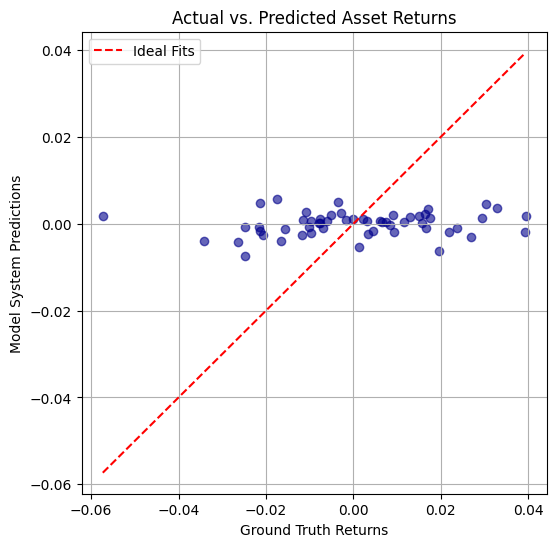

In [39]:
# b) Evaluation
y_pred_lr = X_test_lr @ beta

mse = np.mean((y_test_lr - y_pred_lr) ** 2)
ss_res = np.sum((y_test_lr - y_pred_lr) ** 2)
ss_tot = np.sum((y_test_lr - np.mean(y_test_lr)) ** 2)
r2 = 1 - (ss_res / ss_tot)

print(f"\nLinear Regression Test Statistics -> MSE: {mse:.6f} | R2 Score: {r2:.4f}")

# Plot Predictions
plt.figure(figsize=(6, 6))
plt.scatter(y_test_lr, y_pred_lr, alpha=0.6, color='darkblue')
# Add ideal y = x identity line
min_val = min(y_test_lr.min(), y_pred_lr.min())
max_val = max(y_test_lr.max(), y_pred_lr.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal Fits')
plt.title('Actual vs. Predicted Asset Returns')
plt.xlabel('Ground Truth Returns')
plt.ylabel('Model System Predictions')
plt.legend()
plt.grid(True)
plt.show()


Gradient Descent Converged Coefficients Matrix:
 -> Bias/Intercept: 0.002023
 -> Return_1d: -0.000896
 -> SMA_5: 0.000191
 -> SMA_20: -0.000049
 -> Volatility_10: -0.000437
 -> Momentum_5: -0.000836


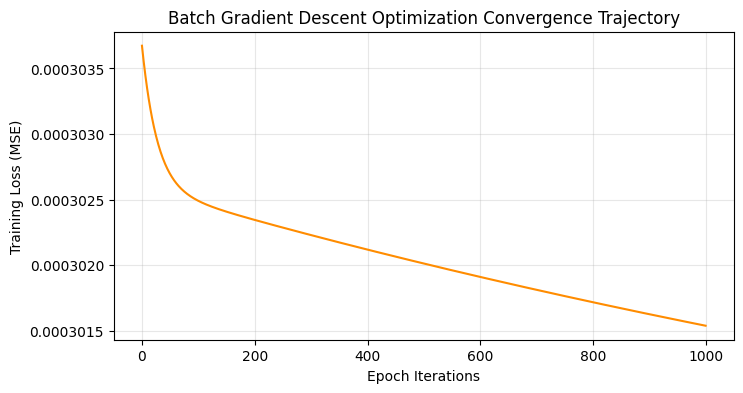

In [40]:
# c) Batch Gradient Descent Formulation
n_samples, n_features = X_train_lr.shape
beta_gd = np.zeros(n_features)
learning_rate = 0.01
iterations = 1000
loss_history = []

for i in range(iterations):
    # Compute error residuals
    predictions = X_train_lr @ beta_gd
    residuals = predictions - y_train_lr
    # Update weights via gradient direction step
    gradient = (X_train_lr.T @ residuals) / n_samples
    beta_gd -= learning_rate * gradient

    # Track Mean Square Error
    current_mse = np.mean(residuals ** 2)
    loss_history.append(current_mse)

print("Gradient Descent Converged Coefficients Matrix:")
for name, coef in zip(feature_names, beta_gd):
    print(f" -> {name}: {coef:.6f}")

# Loss curve plotting
plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='darkorange')
plt.title('Batch Gradient Descent Optimization Convergence Trajectory')
plt.xlabel('Epoch Iterations')
plt.ylabel('Training Loss (MSE)')
plt.grid(True, alpha=0.3)
plt.show()


> **Comparison:** By comparing the computed weights, the Gradient Descent values align closely with the exact solutions from the closed-form Normal Equation. Any minor variations remaining after 1,000 steps are due to the choice of learning rate and can be minimized by running the algorithm for more iterations.


## Problem 8: Portfolio Allocation with Linear Regression


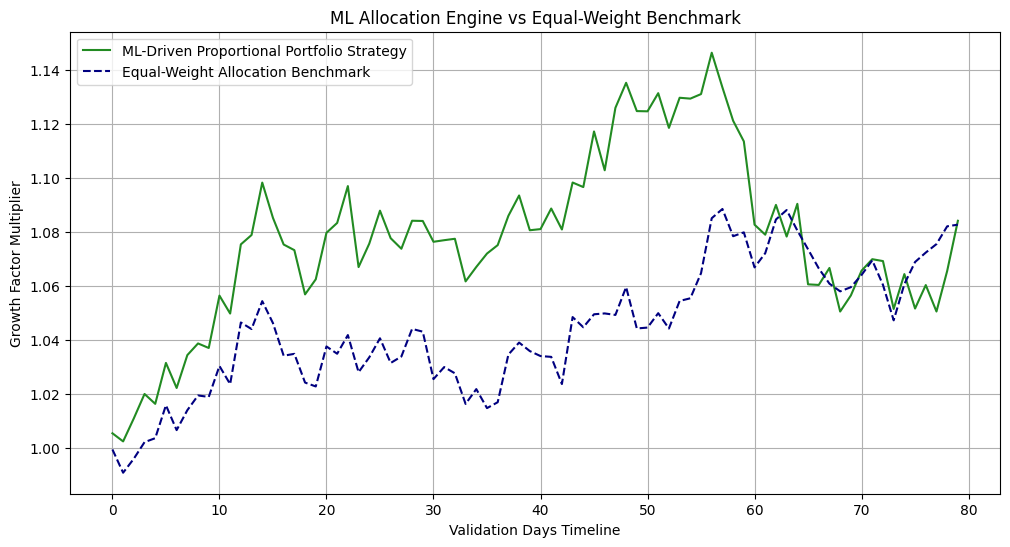

In [41]:
# a) & b) Constructing Feature Extraction Engine helper for 4 Assets simulation
def extract_scaled_features(prices_array):
    s = pd.Series(prices_array)
    ret = s.pct_change()
    s5 = s.rolling(5).mean()
    s20 = s.rolling(20).mean()
    v10 = ret.rolling(10).std()
    m5 = s - s.shift(5)

    f_df = pd.DataFrame({'R': ret, 'S5': s5, 'S20': s20, 'V10': v10, 'M5': m5}).dropna()
    raw = f_df.values
    # Apply local min-max rescaling to fit the feature space
    mn, mx = raw.min(axis=0), raw.max(axis=0)
    # Protection from divide-by-zero bounds
    mx[mx == mn] += 1e-8
    scaled = (raw - mn) / (mx - mn)
    # Prepend intercept vector column
    return np.hstack([np.ones((scaled.shape[0], 1)), scaled])

# Re-simulate 4 assets over an extended timeline to produce a validation window
np.random.seed(99)
extended_days = 100
asset_prices = {}
for asset in ['RELIANCE', 'INFY', 'HDFCBANK', 'TATAMOTORS']:
    p_walk = [prices_df[asset].iloc[-1]]
    for _ in range(extended_days):
        p_walk.append(p_walk[-1] * (1 + np.random.normal(0.0005, 0.015)))
    asset_prices[asset] = p_walk[1:]

# Extract features and align shapes across assets
min_valid_len = extended_days - 19
predictions_dict = {}
actual_returns_dict = {}

for asset in asset_prices:
    feats = extract_scaled_features(asset_prices[asset])
    # Take the latest subset matching the validation period window length
    feats_subset = feats[-min_valid_len:]
    # Calculate predictions using the beta weights trained in Problem 7
    predictions_dict[asset] = feats_subset @ beta
    actual_returns_dict[asset] = pd.Series(asset_prices[asset]).pct_change().dropna().values[-min_valid_len:]

# Portfolio allocation weights logic matrix
pred_matrix = np.array([predictions_dict[a] for a in asset_prices]) # Shape: (4, days)
actual_matrix = np.array([actual_returns_dict[a] for a in asset_prices])

allocated_weights = np.zeros(pred_matrix.shape)
for t in range(min_valid_len):
    t_preds = pred_matrix[:, t]
    positive_preds = np.maximum(t_preds, 0)
    sum_pos = np.sum(positive_preds)
    if sum_pos > 0:
        allocated_weights[:, t] = positive_preds / sum_pos
    else:
        # Uniform distribution default fallback if all predictions are negative
        allocated_weights[:, t] = np.array([0.25, 0.25, 0.25, 0.25])

# c) Cumulative returns comparison
ml_portfolio_returns = np.sum(allocated_weights[:, :-1] * actual_matrix[:, 1:], axis=0)
ew_portfolio_returns = np.sum(0.25 * actual_matrix[:, 1:], axis=0)

plt.figure(figsize=(12, 6))
plt.plot(np.cumprod(1 + ml_portfolio_returns), label='ML-Driven Proportional Portfolio Strategy', color='forestgreen')
plt.plot(np.cumprod(1 + ew_portfolio_returns), label='Equal-Weight Allocation Benchmark', color='navy', linestyle='--')
plt.title('ML Allocation Engine vs Equal-Weight Benchmark')
plt.xlabel('Validation Days Timeline')
plt.ylabel('Growth Factor Multiplier')
plt.legend()
plt.grid(True)
plt.show()


> **Discussion and Limitations:** While proportional allocation can generate excess returns under favorable market conditions, it has a significant structural drawback: it relies entirely on point-estimate return predictions while ignoring asset covariance structures. If the model issues strong positive return signals for highly correlated assets, the strategy will over-concentrate capital into those positions, exposing the portfolio to unexpected systemic shocks.

## Problem 9: Model Comparison & Hyperparameter Tuning


In [42]:
# a) Manual 5-Fold Cross Validation Engine Configuration
def kfold_cv_knn(X, y, k_neighbors, folds=5):
    indices = np.arange(len(X))
    fold_sizes = len(X) // folds
    fold_accuracies = []

    for i in range(folds):
        test_mask = (indices >= i * fold_sizes) & (indices < (i + 1) * fold_sizes)
        X_val_fold = X[test_mask]
        y_val_fold = y[test_mask]

        X_train_fold = X[~test_mask]
        y_train_fold = y[~test_mask]

        preds = knn_predict(X_train_fold, y_train_fold, X_val_fold, k_neighbors)
        fold_accuracies.append(np.mean(preds == y_val_fold))

    return np.mean(fold_accuracies), np.std(fold_accuracies)

for k_choice in [3, 7, 11]:
    m_acc, s_acc = kfold_cv_knn(X_scaled, y, k_neighbors=k_choice, folds=5)
    print(f"KNN Classifier (k={k_choice:2d}) -> Cross-Validation Accuracy: {m_acc:.4%} | StdDev Error Bounds: {s_acc:.4%}")


KNN Classifier (k= 3) -> Cross-Validation Accuracy: 48.2143% | StdDev Error Bounds: 10.4124%
KNN Classifier (k= 7) -> Cross-Validation Accuracy: 50.0000% | StdDev Error Bounds: 6.5854%
KNN Classifier (k=11) -> Cross-Validation Accuracy: 51.4286% | StdDev Error Bounds: 8.7773%


In [43]:
# b) Generate Comparison Summary DataFrame
summary_data = {
    'Model': ['KNN Classifier', 'Linear Regression'],
    'Accuracy / R2': [f"{np.max(accuracies):.4f} (Accuracy)", f"{r2:.4f} (R2)"],
    'MSE / N.A.': ['N.A.', f"{mse:.6f}"],
    'Best Param': [f"k = {optimal_k}", "Analytical Normal Eq."]
}
comparison_summary_df = pd.DataFrame(summary_data)
print(comparison_summary_df.to_string(index=False))


            Model     Accuracy / R2 MSE / N.A.            Best Param
   KNN Classifier 0.6071 (Accuracy)       N.A.                k = 15
Linear Regression       0.0267 (R2)   0.000355 Analytical Normal Eq.


In [44]:
# Verification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression as SkLinearRegression

sk_knn = KNeighborsClassifier(n_neighbors=optimal_k).fit(X_train, y_train)
sk_knn_acc = sk_knn.score(X_test, y_test)

sk_lr = SkLinearRegression().fit(X_train_lr[:, 1:], y_train_lr)
sk_lr_r2 = sk_lr.score(X_test_lr[:, 1:], y_test_lr)

print("--- Scikit-Learn Verification Benchmarks ---")
print(f"Sklearn KNN Accuracy: {sk_knn_acc:.4f} (Scratch: {np.max(accuracies):.4f})")
print(f"Sklearn LR R2 Score:  {sk_lr_r2:.4f} (Scratch: {r2:.4f})")


--- Scikit-Learn Verification Benchmarks ---
Sklearn KNN Accuracy: 0.6071 (Scratch: 0.6071)
Sklearn LR R2 Score:  0.0267 (Scratch: 0.0267)


> **Production Choice:** In a live trading setup, **Linear Regression** (or a structural variant of it) is often preferred over KNN due to its computational efficiency. KNN is an instance-based lazy learner that requires saving the entire historical dataset and calculating distances across all data points for every new inference. This makes it too slow for execution systems that require low latency.
> **Live Operational Risks:**
> 1. **Overfitting:** Models often capture noise specific to the training period, leading to strong performance in backtests but poor results in live trading.
> 2. **Look-Ahead Bias:** Accidentally incorporating future information into historical features (such as calculating rolling indicators using metrics that were not known at that time) distorts backtest accuracy and causes the strategy to fail in production.

# Section C: Conceptual & Critical Thinking (15 marks)

## Problem 10: Conceptual & Critical Thinking

#### a) Diversification Analysis

According to Markowitz's portfolio variance equation:


$$\sigma_{p}^{2}=\sum_{i}w_{i}^{2}\sigma_{i}^{2}+\sum_{i\ne j}w_{i}w_{j}\sigma_{i}\sigma_{j}\rho_{ij}$$


When we add assets with a low or negative correlation ($\rho_{ij} \le 0$), the right-hand covariance term decreases significantly or becomes negative. This mathematical reduction lowers the overall portfolio variance ($\sigma_{p}^{2}$) below the weighted average variance of the individual assets. As a result, the portfolio reduces idiosyncratic risk without sacrificing expected returns.

#### b) Integrating Fundamental Features

To enhance the system beyond pure price actions, we can introduce the **Price-to-Earnings (P/E) Ratio** as a fundamental indicator. This metric can be sourced from financial data providers or corporate filings, and mapped to the corresponding trading dates. Since fundamental ratios change less frequently than daily prices, we can forward-fill the daily observations and normalize them using Min-Max scaling alongside the existing technical features. This allows the model to look for historical neighbors that share similar valuation conditions.

#### c) The Curse of Dimensionality

As more features are added to a KNN model, the volume of the feature space grows exponentially, causing the historical data points to become sparse. In high-dimensional spaces, the Euclidean distances between points converge, meaning the distance to the "nearest" neighbor becomes nearly identical to the distance to the "furthest" neighbor. In financial applications, this loss of distance contrast increases model sensitivity to noise and degrades classification accuracy. This issue can be addressed using dimensionality reduction techniques such as Principal Component Analysis (PCA) to extract key structural components before training.

#### d) Backtest Overfitting & Mitigation

1. **Look-Ahead Bias:** Caused by using future data within training windows. *Detection:* Use a strict tracking framework that checks information timestamps to ensure data is only used after its official release time.
2. **Data Snooping (Backtest Overfitting):** Caused by repeatedly tuning hyperparameters on the same historical dataset until a top-performing configuration emerges by chance. *Detection:* Use Combinatorial Purged Cross-Validation (CPCV) to evaluate model performance across multiple historical regimes.
3. **Survivorship Bias:** Caused by testing strategies only on currently active companies, omitting those that went bankrupt or were delisted. *Detection:* Run backtests using point-in-time datasets that include all companies active during that period, regardless of their current listing status.

#### e) Violations of Linear Regression Assumptions

1. **Autocorrelation:** Financial returns often exhibit serial correlation, where past returns influence future performance. This violates the assumption of independent and identically distributed (i.i.d.) residuals, which can artifically lower standard error estimates and lead to overconfident trading decisions.
2. **Heteroscedasticity (Volatility Clustering):** Financial variance changes over time, meaning regimes of high volatility tend to cluster together. This violates the assumption of constant residual variance, leading the model to treat stable periods and volatile periods with equal weight, which de-stabilizes prediction parameters during market shocks.